
===== kNN CLASSIFICATION (Iris Dataset) =====

Accuracy (k=5): 1.00


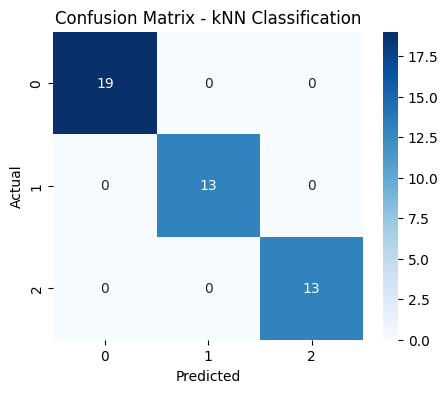


===== kNN REGRESSION =====

MSE (k=5): 522.32
R² Score (k=5): 0.94


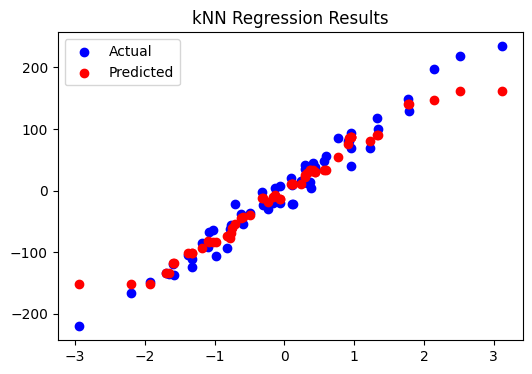

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris, make_regression
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error, r2_score

# Set random seed
np.random.seed(42)

# =====================================
# PART 1: kNN CLASSIFICATION (IRIS)
# =====================================

print("\n===== kNN CLASSIFICATION (Iris Dataset) =====\n")

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Feature scaling (important for kNN)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create kNN classifier
k = 5
clf = KNeighborsClassifier(n_neighbors=k)

# Train model
clf.fit(X_train, y_train)

# Predictions
y_pred = clf.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy (k={k}): {accuracy:.2f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - kNN Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# =====================================
# PART 2: kNN REGRESSION
# =====================================

print("\n===== kNN REGRESSION =====\n")

# Generate synthetic regression dataset
X_reg, y_reg = make_regression(
    n_samples=200, n_features=1, noise=15, random_state=42
)

# Train-test split
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=42
)

# Scale features
scaler_reg = StandardScaler()
Xr_train = scaler_reg.fit_transform(Xr_train)
Xr_test = scaler_reg.transform(Xr_test)

# Create kNN regressor
k_reg = 5
reg = KNeighborsRegressor(n_neighbors=k_reg)

# Train model
reg.fit(Xr_train, yr_train)

# Predictions
yr_pred = reg.predict(Xr_test)

# Evaluation
mse = mean_squared_error(yr_test, yr_pred)
r2 = r2_score(yr_test, yr_pred)

print(f"MSE (k={k_reg}): {mse:.2f}")
print(f"R² Score (k={k_reg}): {r2:.2f}")

# Plot regression results
plt.figure(figsize=(6,4))
plt.scatter(Xr_test, yr_test, color='blue', label='Actual')
plt.scatter(Xr_test, yr_pred, color='red', label='Predicted')
plt.title("kNN Regression Results")
plt.legend()
plt.show()